# ViT Encoder + LSTM Decoder Training
Frozen `facebook/dinov2-base` encoder with a trainable LSTM decoder for handwritten math → LaTeX.

In [1]:
!pip install -q transformers datasets
!pip -q install peft accelerate

In [2]:
import numpy as np
import pickle
from pickle import load
import random
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from transformers import ViTModel
from pathlib import Path
from datasets import load_from_disk, load_dataset
from peft import LoraConfig, get_peft_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import GPT2Config, GPT2LMHeadModel, GPT2TokenizerFast
from transformers import AutoModel
from PIL import Image
import torchvision.transforms as T
import gc
from PIL import ImageDraw

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

2026-03-13 00:15:19.409919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773360919.594059      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773360919.646970      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773360920.075838      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773360920.075886      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773360920.075888      24 computation_placer.cc:177] computation placer alr

Using device: cuda


## 1. Load & preprocess dataset

In [3]:
for f in sorted(Path("/kaggle/input/datasets").rglob("*")):
    print(f)

/kaggle/input/datasets/martinvu7
/kaggle/input/datasets/martinvu7/vit-transformer
/kaggle/input/datasets/martinvu7/vit-transformer/dinov2_attn_lora.pt


In [4]:
print("Loading dataset...")
ds = load_dataset("deepcopy/MathWriting-human")
num_samples = 40000
ds_train = ds["train"].select(range(num_samples))

# 2. Pre-allocate Image Array (Saves RAM by avoiding copies)
print(f"Pre-allocating memory for {num_samples} images...")
images_array = np.zeros((num_samples, 224, 224, 3), dtype=np.uint8) # Uses uint8 instead of float to save RAM
latex_strings = []

# 3. Process Images & Collect Strings
print("Processing images and LaTeX strings...")
for i in range(num_samples):
    sample = ds_train[i]
    # Convert and resize directly into the array
    img = sample["image"].convert("RGB")
    
    img.thumbnail((224, 224)) 
    
    # Create 224x224 white background
    new_img = Image.new("RGB", (224, 224), (255, 255, 255))
    
    # center the image
    x_offset = (224 - img.size[0]) // 2
    y_offset = (224 - img.size[1]) // 2
    new_img.paste(img, (x_offset, y_offset))
    
    images_array[i] = np.array(new_img, dtype=np.uint8)
    latex_strings.append(sample["latex"])
    
    if (i + 1) % 5000 == 0:
        print(f"Progress: {i + 1}/{num_samples}")

# 4. Setup Tokenizer
print("Fitting tokenizer...")
tokenizer = Tokenizer(char_level=True, filters='', lower=False)
tokenizer.fit_on_texts(latex_strings)

# Add special tokens
tokenizer.word_index["<START>"] = len(tokenizer.word_index) + 1
tokenizer.word_index["<END>"] = len(tokenizer.word_index) + 1
tokenizer.index_word[tokenizer.word_index["<START>"]] = "<START>"
tokenizer.index_word[tokenizer.word_index["<END>"]] = "<END>"

START_ID = tokenizer.word_index["<START>"]
END_ID   = tokenizer.word_index["<END>"]

# 5. Sequence Padding
print("Tokenizing and padding sequences...")
sequences = tokenizer.texts_to_sequences(latex_strings)
sequences = [[START_ID] + seq + [END_ID] for seq in sequences]
padded_sequences = pad_sequences(sequences, padding="post")

# 6. Save Tokenizer and Vocab Info
print("Saving metadata...")
with open("/kaggle/working/latex_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

vocab_size = len(tokenizer.word_index) + 1
with open("/kaggle/working/vocab_size.txt", "w") as f:
    f.write(str(vocab_size))

# 7. Convert to Tensors and Save (Disk usage check: ~13.5GB total)
print("Converting to Tensors...")
# torch.from_numpy avoids a RAM copy
images_tensor = torch.from_numpy(images_array).permute(0, 3, 1, 2) 
tokens_tensor = torch.tensor(padded_sequences, dtype=torch.long)
print("Images:", images_tensor.shape)
print("Tokens:", tokens_tensor.shape)

print("Saving tensors to disk (this takes a minute)...")
torch.save(images_tensor, "/kaggle/working/images_train.pt")
torch.save(tokens_tensor, "/kaggle/working/tokens_train.pt")

print("Done!")
print(f"Final Vocab Size: {vocab_size}")
print(f"Image Tensor Shape: {images_tensor.shape}")

del images_array
del latex_strings
del ds
gc.collect()


Loading dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003-ab0ae6b9fa4a3f(…):   0%|          | 0.00/373M [00:00<?, ?B/s]

data/train-00001-of-00003-589d2b65116e09(…):   0%|          | 0.00/374M [00:00<?, ?B/s]

data/train-00002-of-00003-42472859069c07(…):   0%|          | 0.00/373M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/229864 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7644 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/15674 [00:00<?, ? examples/s]

Pre-allocating memory for 40000 images...
Processing images and LaTeX strings...
Progress: 5000/40000
Progress: 10000/40000
Progress: 15000/40000
Progress: 20000/40000
Progress: 25000/40000
Progress: 30000/40000
Progress: 35000/40000
Progress: 40000/40000
Fitting tokenizer...
Tokenizing and padding sequences...
Saving metadata...
Converting to Tensors...
Images: torch.Size([40000, 3, 224, 224])
Tokens: torch.Size([40000, 159])
Saving tensors to disk (this takes a minute)...
Done!
Final Vocab Size: 92
Image Tensor Shape: torch.Size([40000, 3, 224, 224])


98

In [5]:
ds = load_dataset("deepcopy/MathWriting-human")

ds_val = ds["val"].select(range(500))

images, sequences = [], []
def preprocess_image(img, target_size=(224, 224)):
    img = img.convert("RGB")

    img.thumbnail(target_size)

    new_img = Image.new("RGB", target_size, (255, 255, 255))

    x_offset = (target_size[0] - img.size[0]) // 2
    y_offset = (target_size[1] - img.size[1]) // 2
    new_img.paste(img, (x_offset, y_offset))

    img = np.array(new_img, dtype=np.uint8)
    return img

for sample in ds_val:
    img = preprocess_image(sample["image"])
    images.append(img)
    sequences.append(sample["latex"])

images = np.array(images)
with open("/kaggle/working/latex_tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

START_ID = tokenizer.word_index["<START>"]
END_ID   = tokenizer.word_index["<END>"]

seqs = tokenizer.texts_to_sequences(sequences)
seqs = [[START_ID] + s + [END_ID] for s in seqs]

padded_sequences = pad_sequences(seqs, padding="post")

images_tensor = torch.from_numpy(images).permute(0, 3, 1, 2)
tokens_tensor = torch.tensor(padded_sequences, dtype=torch.long)

torch.save(images_tensor, "/kaggle/working/images_val.pt")
torch.save(tokens_tensor, "/kaggle/working/tokens_val.pt")
print("Images:", images_tensor.shape)
print("Tokens:", tokens_tensor.shape)

Images: torch.Size([500, 3, 224, 224])
Tokens: torch.Size([500, 102])


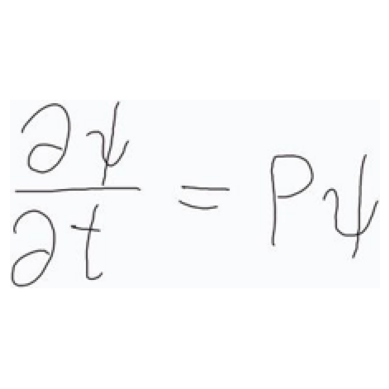

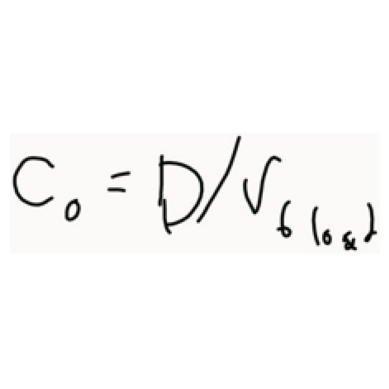

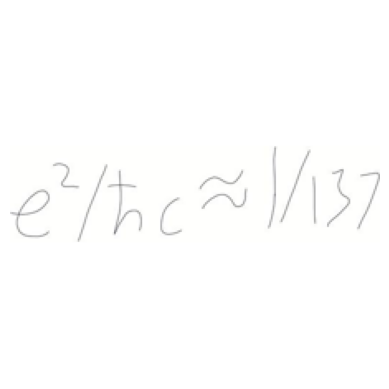

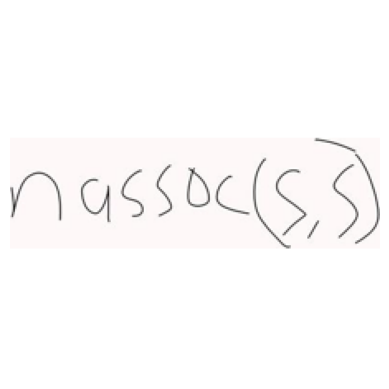

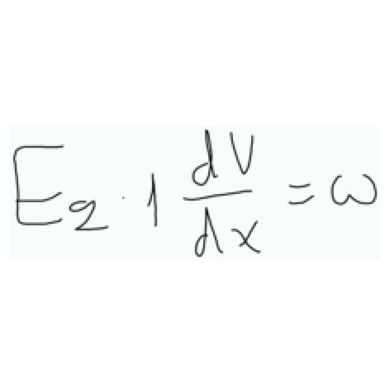

In [6]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(images[i])
    plt.axis("off")
    plt.show()

## 2. Model definition

In [7]:
def list_linear_suffixes(model):
    suffixes = set()
    examples = []
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear):
            suf = name.split(".")[-1]
            suffixes.add(suf)
            if len(examples) < 30:
                examples.append(name)
    print("Unique Linear suffixes:", sorted(suffixes))
    print("\nExample Linear module names:")
    for e in examples:
        print("  ", e)

In [8]:
class ViTLatexModelLoRA(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, nhead=8, num_layers=6,
             lora_r=32, lora_alpha=64, lora_dropout=0.1,
             dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("facebook/dinov2-base")
        target_modules = ["query", "key", "value", "dense", "fc1", "fc2"]
        
        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            bias="none",
            target_modules=target_modules,
            task_type="FEATURE_EXTRACTION",  # safe default for encoder-only usage
        )
        self.encoder = get_peft_model(self.encoder, lora_cfg)
        encoder_dim = self.encoder.config.hidden_size  # 768

        # Decoder embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = nn.Parameter(torch.randn(1, 1000, embed_dim) * 0.02)  # max seq length

        # Transformer decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # linear projection to vocab
        self.fc_out = nn.Linear(embed_dim, vocab_size)

        # project encoder dim to decoder embedding
        if encoder_dim != embed_dim:
            self.enc_proj = nn.Linear(encoder_dim, embed_dim)
        else:
            self.enc_proj = nn.Identity()

    def forward(self, images, input_tokens):
        """
        images: (B, 3, H, W)
        input_tokens: (B, T)
        """
        enc = self.encoder(pixel_values=images).last_hidden_state  # (B, N, D)
        enc = self.enc_proj(enc)  # (B, N, E)
    
        # Decoder embedding + positions
        emb = self.embedding(input_tokens) + self.pos_encoder[:, :input_tokens.size(1), :]  # (B, T, E)
    
        # Causal mask for decoder
        T = input_tokens.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(T, device=images.device)
    
        # PAD mask (ignore padded tokens)
        PAD_ID = 0  
        tgt_key_padding_mask = (input_tokens == PAD_ID)  # True where padding
    
        # Transformer decoder
        dec_out = self.transformer_decoder(
            tgt=emb,
            memory=enc,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )  # (B, T, E)
    
        # Project to vocab
        logits = self.fc_out(dec_out)  # (B, T, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, image, max_len=150, sos_idx=1, eos_idx=2):
        self.eval()
        device = image.device
        if image.ndim == 3: image = image.unsqueeze(0) # Batch dim fix

        enc = self.encoder(pixel_values=image).last_hidden_state
        enc = self.enc_proj(enc)
    
        tokens = torch.tensor([[sos_idx]], device=device)
        for _ in range(max_len):
            T = tokens.size(1)
            emb = self.embedding(tokens) + self.pos_encoder[:, :T, :]
            mask = nn.Transformer.generate_square_subsequent_mask(T, device=device)
            
            out = self.transformer_decoder(tgt=emb, memory=enc, tgt_mask=mask)
            logits = self.fc_out(out[:, -1, :])
            next_token = logits.argmax(dim=-1, keepdim=True)
            
            if next_token.item() == eos_idx: break
            tokens = torch.cat([tokens, next_token], dim=1)
    
        return tokens[0, 1:].tolist()

## 3. Training

In [9]:
# Load vocab size
with open("/kaggle/working/vocab_size.txt") as f:
    VOCAB_SIZE = int(f.read().strip())

# Hyperparameters
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE_DEC = 3e-4  # decoder
LEARNING_RATE_ENC = 5e-5  # LoRA adapters in encoder

# Load pre-processed tensors (just load, don't convert yet)
images_tensor = torch.load(f"/kaggle/working/images_train.pt")    # (40000, 3, 224, 224)
tokens_tensor = torch.load(f"/kaggle/working/tokens_train.pt")  # (40000, seq_len)

images_val = torch.load("/kaggle/working/images_val.pt")
tokens_val = torch.load("/kaggle/working/tokens_val.pt")

val_images = images_val.to(DEVICE)
val_tokens = tokens_val.to(DEVICE)

VOCAB_SIZE = 92
START_TOKEN = VOCAB_SIZE - 2
END_TOKEN = VOCAB_SIZE - 1
MAX_LEN = 150

with open("/kaggle/working/latex_tokenizer.pkl", "rb") as f:
    tokenizer = load(f)

inv_vocab = {v: k for k, v in tokenizer.word_index.items()}

def decode(seq):
    filtered = [t for t in seq if t != START_TOKEN and t != END_TOKEN and t != 0]
    return "".join(inv_vocab.get(t, "") for t in filtered)

print(f"Images: {images_tensor.shape}, Tokens: {tokens_tensor.shape}, Vocab size: {VOCAB_SIZE}")

# Create dataset and loader
dataset = TensorDataset(images_tensor, tokens_tensor)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize model
model = ViTLatexModelLoRA(vocab_size=VOCAB_SIZE).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
#optimizer = torch.optim.Adam(model.decoder.parameters(), lr=LEARNING_RATE)

# 1. Filter out the encoder from the general groups
# 2. Split general groups into decay (weights) and no_decay (biases/LayerNorm)
no_decay = ["bias", "LayerNorm.weight"]

# Get all decoder/misc parameters (exclude encoder)
decoder_params = [(n, p) for n, p in model.named_parameters() 
                  if "encoder" not in n and p.requires_grad]

optimizer_grouped_parameters = [
    # Group 1: Decoder Weights (with Decay)
    {
        "params": [p for n, p in decoder_params if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01, 
        "lr": LEARNING_RATE_DEC
    },
    # Group 2: Decoder Biases/LayerNorm (NO Decay)
    {
        "params": [p for n, p in decoder_params if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
        "lr": LEARNING_RATE_DEC
    },
    # Group 3: Encoder (LoRA) - Decay 0.0 is safe for LoRA adapters
    {
        "params": [p for p in model.encoder.parameters() if p.requires_grad],
        "weight_decay": 0.0,
        "lr": LEARNING_RATE_ENC
    }
]

optimizer = torch.optim.AdamW(optimizer_grouped_parameters)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LEARNING_RATE_DEC, LEARNING_RATE_DEC, LEARNING_RATE_ENC],
    steps_per_epoch=len(loader),
    epochs=EPOCHS,
    pct_start=0.1,    # 10% Warmup
    div_factor=10,    # Start at 1/10th of max
    final_div_factor=100
)


mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1,3,1,1)

# Training loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for batch_idx, (imgs, seqs) in enumerate(loader):
        # Convert grayscale to RGB
        imgs = imgs.to(DEVICE, dtype=torch.float32) / 255.0
        imgs = (imgs - mean) / std
        
        seqs = seqs.to(DEVICE)
        
        # Teacher forcing
        input_tokens = seqs[:, :-1]   # (B, seq_len-1)
        target_tokens = seqs[:, 1:]   # (B, seq_len-1)
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(imgs, input_tokens)
        
        # Compute loss
        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),  # (B * (seq_len-1), vocab_size)
            target_tokens.reshape(-1)         # (B * (seq_len-1))
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Print every 100 batches
        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.4f}")
    
    print(f"Epoch {epoch + 1}/{EPOCHS} | Avg Loss: {total_loss / len(loader):.4f}")
    # Save a backup after every epoch
    torch.save({"model": model.state_dict()}, f"/kaggle/working/checkpoint_ep{epoch+1}.pt")
    model.eval()

    N = 500   # number of validation samples (use small subset for speed)
    exact_matches = 0
    
    for i in range(N):
        img = val_images[i:i+1] / 255.0
        img = (img - mean) / std
        
        gt_tokens = val_tokens[i]
        
        pred_tokens = model.generate(
            img,
            max_len=MAX_LEN,
            sos_idx=START_TOKEN,
            eos_idx=END_TOKEN
        )
        
        ground_truth = decode(gt_tokens.tolist())
        prediction = decode(pred_tokens)
        
        if prediction == ground_truth:
            exact_matches += 1
    
    val_acc = exact_matches / N
    print(f"Validation Exact Match: {val_acc:.2%}")
    
    model.train()
# Save model
SAVE_PATH = "/kaggle/working/dinov2_attn_lora.pt"
torch.save({
    "model": model.state_dict()
}, SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")



Images: torch.Size([40000, 3, 224, 224]), Tokens: torch.Size([40000, 159]), Vocab size: 92


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Trainable params: 31,532,636 / 118,113,116


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


  Batch 0/2500 | Loss: 4.7345
  Batch 100/2500 | Loss: 2.7705
  Batch 200/2500 | Loss: 2.5591
  Batch 300/2500 | Loss: 2.2959
  Batch 400/2500 | Loss: 2.1705
  Batch 500/2500 | Loss: 2.2223
  Batch 600/2500 | Loss: 2.0318
  Batch 700/2500 | Loss: 2.2073
  Batch 800/2500 | Loss: 1.8364
  Batch 900/2500 | Loss: 1.9480
  Batch 1000/2500 | Loss: 1.7182
  Batch 1100/2500 | Loss: 1.7980
  Batch 1200/2500 | Loss: 1.6183
  Batch 1300/2500 | Loss: 1.6092
  Batch 1400/2500 | Loss: 1.5443
  Batch 1500/2500 | Loss: 1.4501
  Batch 1600/2500 | Loss: 1.7382
  Batch 1700/2500 | Loss: 1.5252
  Batch 1800/2500 | Loss: 1.3094
  Batch 1900/2500 | Loss: 1.3698
  Batch 2000/2500 | Loss: 1.3658
  Batch 2100/2500 | Loss: 1.3127
  Batch 2200/2500 | Loss: 1.3569
  Batch 2300/2500 | Loss: 1.3743
  Batch 2400/2500 | Loss: 1.0696
Epoch 1/10 | Avg Loss: 1.7619
Validation Exact Match: 18.20%
  Batch 0/2500 | Loss: 1.3305
  Batch 100/2500 | Loss: 1.3933
  Batch 200/2500 | Loss: 0.9963
  Batch 300/2500 | Loss: 1.2179


## 4. Evals

In [10]:
def normalized_edit_distance(s1, s2):
    if len(s1) == 0 and len(s2) == 0:
        return 0.0
    if len(s1) == 0 or len(s2) == 0:
        return 1.0
    
    # Levenshtein distance
    d = [[0] * (len(s2) + 1) for _ in range(len(s1) + 1)]
    for i in range(len(s1) + 1):
        d[i][0] = i
    for j in range(len(s2) + 1):
        d[0][j] = j
    
    for i in range(1, len(s1) + 1):
        for j in range(1, len(s2) + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            d[i][j] = min(d[i-1][j] + 1, d[i][j-1] + 1, d[i-1][j-1] + cost)
    
    return d[len(s1)][len(s2)] / max(len(s1), len(s2))

In [11]:
# ##### import torch
# from pickle import load

# DATA = "/kaggle/input/datasets/martinvu7/vit-transformer"

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # with open(f"/kaggle/working/vocab_size.txt") as f:
#     # VOCAB_SIZE = int(f.read().strip())
# VOCAB_SIZE = 92
# START_TOKEN = VOCAB_SIZE - 2
# END_TOKEN = VOCAB_SIZE - 1
# MAX_LEN = 150

# # Load model
# model = ViTLatexModelLoRA(vocab_size=VOCAB_SIZE).to(DEVICE)
# checkpoint = torch.load(f"{DATA}/dinov2_attn_lora.pt", map_location=DEVICE)
# model.load_state_dict(checkpoint["model"])
# model.eval()
# # Load validation data
# images = torch.load(f"/kaggle/working/images_val.pt")
# tokens = torch.load(f"/kaggle/working/tokens_val.pt")

# with open(f"/kaggle/working/latex_tokenizer.pkl", "rb") as f:
#     tokenizer = load(f)

# inv_vocab = {v: k for k, v in tokenizer.word_index.items()}

# def decode(seq):
#     # Filter out start and end tokens
#     filtered = [t for t in seq if t != START_TOKEN and t != END_TOKEN and t != 0]
#     return "".join(inv_vocab.get(t, "") for t in filtered)

# # Inference
# N = 50
# exact_matches = 0
# total_edit_dist = 0.0
# print(f"Evaluating on {N} test samples...")
# print("-" * 60)
# mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1,3,1,1)
# std  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1,3,1,1)

# for i in range(N):
#     img = images[i:i+1].to(DEVICE) / 255.0 # (1, 3, 224, 224)
#     img = (img - mean) / std
#     gt_tokens = tokens[i]
    
#     pred_tokens = model.generate(img, max_len=MAX_LEN, sos_idx=START_TOKEN, eos_idx=END_TOKEN)
    
#     ground_truth = decode(gt_tokens.tolist())
#     prediction = decode(pred_tokens)
    
#     is_exact = prediction == ground_truth
#     edit_dist = normalized_edit_distance(prediction, ground_truth)
    
#     if is_exact:
#         exact_matches += 1
#     total_edit_dist += edit_dist
    
#     # status = "EXACT" if is_exact else f"edit_dist={edit_dist:.4f}"
#     # print(f"  [{i+1}/{N}] {status}")
#     # print(f"    GT:   {ground_truth[:80]}")
#     # print(f"    PRED: {prediction[:80]}")
#     # print("-"*40)

# accuracy = exact_matches / N
# avg_edit_dist = total_edit_dist / N

# print("\n" + "=" * 60)
# print("SUMMARY")
# print("=" * 60)
# print(f"Model:                    DinoV2 + Transformer")
# print(f"Samples:                  {N}")
# print(f"Exact match accuracy:     {accuracy:.2%} ({exact_matches}/{N})")
# print(f"Avg normalized edit dist: {avg_edit_dist:.4f}")

In [12]:
# import os
# print(os.listdir("/kaggle/input/datasets/martinvu7/vit-transformer"))